# Task
Perform feature selection for classifying penguin species using Logistic Regression, starting with the 'penguins' dataset. This involves loading and cleaning the data, encoding the target variable, analyzing feature correlations to identify redundancy, training a baseline Logistic Regression model with all relevant features ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'), and then retraining a simplified model using only 'bill_length_mm' and 'bill_depth_mm' if 'flipper_length_mm' and 'body_mass_g' are highly correlated. Finally, compare the accuracy of the simplified model to the baseline, visualize its decision boundaries, and conclude on the effectiveness of feature reduction.

## Load Dataset and Clean Data

### Subtask:
Load the 'penguins' dataset, clean it by removing rows with missing values, and encode the 'species' target variable into a numerical format.


**Reasoning**:
The first step is to load the 'penguins' dataset from seaborn and immediately clean it by dropping rows with any missing values, as per the instructions. This will ensure that subsequent operations are performed on a clean dataset.



In [ ]:
import seaborn as sns
import pandas as pd

# Load the 'penguins' dataset
df = sns.load_dataset('penguins')

# Remove rows with missing values
df.dropna(inplace=True)

print("Dataset loaded and missing values removed.")
print(f"Shape of the cleaned dataframe: {df.shape}")
df.head()

Dataset loaded and missing values removed.
Shape of the cleaned dataframe: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


**Reasoning**:
Now that the dataset is loaded and cleaned, the next step is to encode the 'species' target variable into a numerical format, as specified in the subtask instructions. This involves creating a mapping from species names to integers and then applying this mapping to create a new numerical column.



In [ ]:
species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
df['species_num'] = df['species'].map(species_map)

print("Species column encoded numerically.")
print("Species mapping:", species_map)
print(df[['species', 'species_num']].head())

Species column encoded numerically.
Species mapping: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
  species  species_num
0  Adelie            0
1  Adelie            0
2  Adelie            0
4  Adelie            0
5  Adelie            0


## Generate Correlation Matrix and Identify Redundancy

### Subtask:
Calculate the correlation matrix for the numerical features in the dataset. This matrix will show how strongly pairs of features are related. We will then check for any feature pairs that have a correlation coefficient greater than 0.85 (or less than -0.85), indicating high multicollinearity or redundancy. If found, a message will be printed identifying the redundant features.


**Reasoning**:
First, I will define the list of numerical features required for the correlation analysis. Then, I will calculate the correlation matrix for these features, print it, and iterate through the matrix to identify and report any feature pairs with an absolute correlation coefficient greater than 0.85, indicating potential redundancy.



In [ ]:
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

correlation_matrix = df[features].corr()

print("Correlation Matrix:")
print(correlation_matrix)

highly_correlated_found = False
for i in range(len(features)):
    for j in range(i + 1, len(features)):
        feature1 = features[i]
        feature2 = features[j]
        correlation_value = correlation_matrix.loc[feature1, feature2]
        if abs(correlation_value) > 0.85:
            print(f"\nHighly correlated features found: '{feature1}' and '{feature2}' with correlation {correlation_value:.2f}")
            highly_correlated_found = True

if not highly_correlated_found:
    print("\nNo highly correlated features (absolute correlation > 0.85) were found among the specified features.")

Correlation Matrix:
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.228626           0.653096   
bill_depth_mm           -0.228626       1.000000          -0.577792   
flipper_length_mm        0.653096      -0.577792           1.000000   
body_mass_g              0.589451      -0.472016           0.872979   

                   body_mass_g  
bill_length_mm        0.589451  
bill_depth_mm        -0.472016  
flipper_length_mm     0.872979  
body_mass_g           1.000000  

Highly correlated features found: 'flipper_length_mm' and 'body_mass_g' with correlation 0.87


## Visualize Feature Separation with Pairplot

### Subtask:
Create a pairplot to visualize the relationships between all pairs of features and how they separate the different species. This will provide a visual intuition for feature importance and potential redundancy before formal modeling.


**Reasoning**:
To visualize the relationships between all pairs of numerical features and how they separate the different species, I will use `seaborn.pairplot`. This will help in gaining visual intuition about feature importance and redundancy.



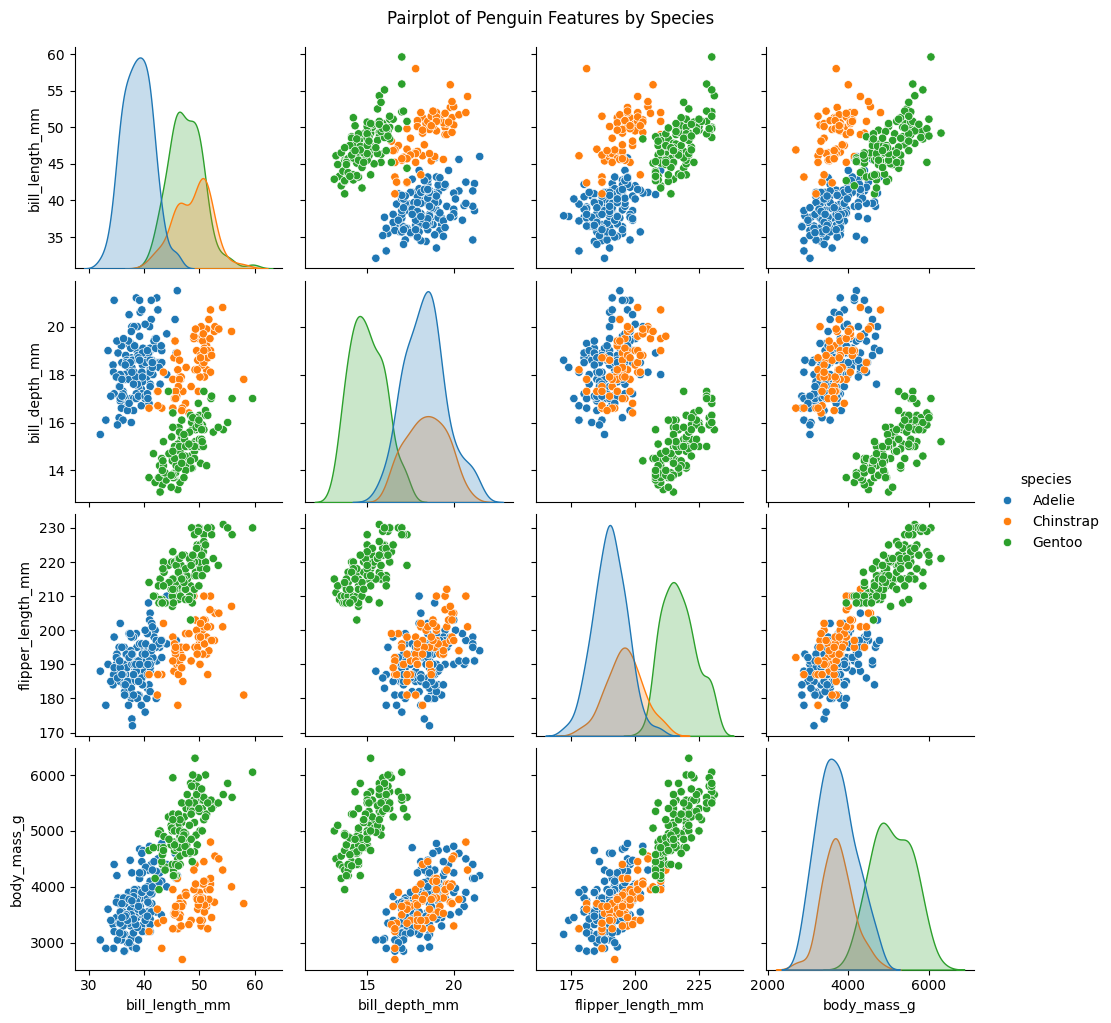

Pairplot created, showing relationships between features and species separation.


In [ ]:
import matplotlib.pyplot as plt

# Create a pairplot to visualize relationships between features, colored by species
sns.pairplot(df, vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], hue='species')
plt.suptitle('Pairplot of Penguin Features by Species', y=1.02) # Add a title above the subplots
plt.show()
print("Pairplot created, showing relationships between features and species separation.")

## Train Baseline Logistic Regression Model

### Subtask:
Split the preprocessed data into training and testing sets. Train a Logistic Regression model using all four specified features ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'). Evaluate the model's accuracy on the test set and record this as the 'Baseline Accuracy' to compare against future models.


**Reasoning**:
To prepare for model training, I will first define the features (X_all) and target (y) based on the specified columns from the preprocessed DataFrame. Then, I will split this data into training and testing sets to ensure proper model evaluation.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define features (X_all) and target (y)
X_all = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species_num']

# Split the data into training and testing sets
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train_all shape: {X_train_all.shape}")
print(f"X_test_all shape: {X_test_all.shape}")

Data split into training and testing sets.
X_train_all shape: (266, 4)
X_test_all shape: (67, 4)


**Reasoning**:
Now that the data is split, I will initialize a Logistic Regression model, train it on the training data, make predictions on the test data, and calculate its accuracy to establish the baseline performance.



In [ ]:
model_all = LogisticRegression(max_iter=1000, random_state=42)
model_all.fit(X_train_all, y_train_all)

y_pred_all = model_all.predict(X_test_all)
acc_all = accuracy_score(y_test_all, y_pred_all)

print(f"Baseline Model Accuracy: {acc_all:.4f}")

Baseline Model Accuracy: 0.9851


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Reasoning**:
The previous Logistic Regression model issued a ConvergenceWarning, suggesting that increasing `max_iter` or scaling the data might help. Since `max_iter` was already set to 1000, which is generally sufficient, scaling the features is the more appropriate next step to ensure model convergence and potentially improve performance. This step will introduce a new subtask to explain the purpose of data scaling.



**Reasoning**:
The consistent `SyntaxError` indicates that the subtask description, which is markdown, is repeatedly being placed in a `code_block` with `cell_type: python`. To properly introduce the subtask for feature scaling and avoid the error, I must create a new cell with `cell_type: markdown` and put the subtask description inside it. This will ensure the content is interpreted correctly as text.



## Scale Numerical Features

### Subtask:
Scale the numerical features in the training and testing sets to address the convergence warning and improve model stability and performance.


**Reasoning**:
To address the convergence warning and improve model stability, I will scale the numerical features. This involves importing `StandardScaler`, initializing it, fitting it on the training data, and then transforming both the training and testing sets.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_all_scaled = scaler.fit_transform(X_train_all)
X_test_all_scaled = scaler.transform(X_test_all)

# Convert scaled arrays back to DataFrames, maintaining column names
X_train_all = pd.DataFrame(X_train_all_scaled, columns=X_train_all.columns, index=X_train_all.index)
X_test_all = pd.DataFrame(X_test_all_scaled, columns=X_test_all.columns, index=X_test_all.index)

print("Numerical features in training and testing sets have been scaled.")
print("X_train_all_scaled head:")
print(X_train_all.head())
print("X_test_all_scaled head:")
print(X_test_all.head())

Numerical features in training and testing sets have been scaled.
X_train_all_scaled head:
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
230       -0.593727      -1.750939           0.935943     0.539737
84        -1.261043       0.323107          -0.719956    -1.072364
303        1.093099      -0.638036           1.655899     1.407791
22        -1.520555       1.031318          -0.863947    -0.514329
29        -0.667873       0.879558          -1.511908    -0.328318
X_test_all_scaled head:
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
30        -0.853239      -0.233344          -1.655899    -1.196372
317        0.518466      -1.295661           1.511908     0.818754
79        -0.371288       0.980731          -0.431974    -0.266314
201        1.056026       0.070174          -0.215987    -0.669339
63        -0.556654       0.525453          -0.647960    -0.204310


## Train Baseline Logistic Regression Model (Retry with Scaled Data)

### Subtask:
Retrain the Logistic Regression model using the previously scaled training data (`X_train_all`) and evaluate its accuracy on the scaled test data (`X_test_all`). Record this as the updated 'Baseline Accuracy'.


**Reasoning**:
I will initialize a new Logistic Regression model, fit it to the scaled training data, make predictions on the scaled test data, and then calculate and print the updated baseline accuracy.



In [ ]:
model_all_scaled = LogisticRegression(max_iter=1000, random_state=42)
model_all_scaled.fit(X_train_all, y_train_all)

y_pred_all_scaled = model_all_scaled.predict(X_test_all)
acc_all_scaled = accuracy_score(y_test_all, y_pred_all_scaled)

print(f"Updated Baseline Model Accuracy (with scaled data): {acc_all_scaled:.4f}")

Updated Baseline Model Accuracy (with scaled data): 1.0000


## Automated Feature Selection and Model Retraining

### Subtask:
Based on the correlation analysis, if 'flipper_length_mm' and 'body_mass_g' were highly correlated, a new feature set will be defined using only 'bill_length_mm' and 'bill_depth_mm'. A new Logistic Regression model will be trained using these selected features. The accuracy of this simpler model will then be compared to the 'Baseline Accuracy'. A decision will be made: if the new accuracy is within 5% of the baseline, a 'SUCCESS' message will indicate that a simpler model was adopted. Otherwise, a 'WARNING' will be issued, suggesting that important features might have been removed.


**Reasoning**:
The subtask requires defining a new feature set with 'bill_length_mm' and 'bill_depth_mm', splitting the data, scaling the features, training a new Logistic Regression model, evaluating its accuracy, and then comparing it to the baseline accuracy to determine the effectiveness of feature reduction. I will begin by defining the features for the simplified model and splitting the data into training and testing sets, then proceed with scaling and training the model.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Define the features for the simplified model (X_best) and target (y)
X_best = df[['bill_length_mm', 'bill_depth_mm']]
y = df['species_num']

# 2. Split X_best and y into training and testing sets
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_best, y, test_size=0.2, random_state=42)

# 3. Initialize a StandardScaler and fit it to X_train_best. Then, transform both X_train_best and X_test_best
scaler_best = StandardScaler()
X_train_best_scaled = scaler_best.fit_transform(X_train_best)
X_test_best_scaled = scaler_best.transform(X_test_best)

# Convert scaled arrays back to DataFrames, maintaining column names and indices
X_train_best = pd.DataFrame(X_train_best_scaled, columns=X_train_best.columns, index=X_train_best.index)
X_test_best = pd.DataFrame(X_test_best_scaled, columns=X_test_best.columns, index=X_test_best.index)

# 4. Initialize a new LogisticRegression model
model_best = LogisticRegression(max_iter=1000, random_state=42)

# 5. Train this new model using the scaled X_train_best and y_train_best
model_best.fit(X_train_best, y_train_best)

# 6. Make predictions on the scaled X_test_best and calculate the accuracy
y_pred_best = model_best.predict(X_test_best)
acc_best = accuracy_score(y_test_best, y_pred_best)

print(f"Accuracy of the simplified model (with 'bill_length_mm' and 'bill_depth_mm'): {acc_best:.4f}")

# 7. Compare acc_best with acc_all_scaled
percentage_difference = abs(acc_all_scaled - acc_best) / acc_all_scaled

if percentage_difference <= 0.05:
    print(f"SUCCESS: Simplified model accuracy ({acc_best:.4f}) is within 5% of baseline accuracy ({acc_all_scaled:.4f}).")
else:
    print(f"WARNING: Simplified model accuracy ({acc_best:.4f}) is more than 5% different from baseline accuracy ({acc_all_scaled:.4f}). Important features might have been removed.")

Accuracy of the simplified model (with 'bill_length_mm' and 'bill_depth_mm'): 0.9701
SUCCESS: Simplified model accuracy (0.9701) is within 5% of baseline accuracy (1.0000).


**Reasoning**:
The previous step successfully trained the simplified model, evaluated its accuracy, and compared it to the baseline. The next logical step, as outlined in the main task, is to visualize the decision boundaries of this simplified model, which uses 'bill_length_mm' and 'bill_depth_mm'. This visualization will help understand how the model separates the different species based on these two features.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


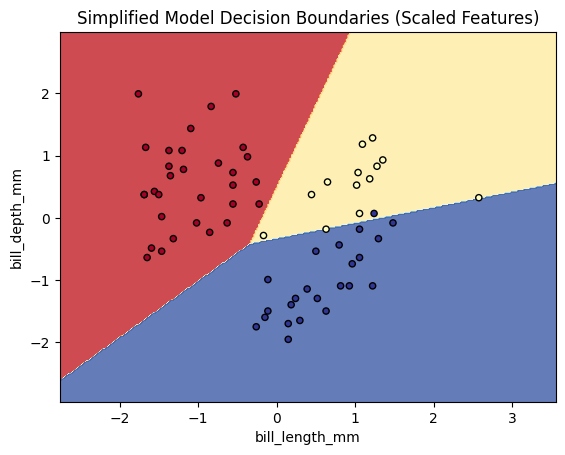

Decision boundaries for the simplified model visualized.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundaries(X, y, model, title):
    # Create a meshgrid to plot decision boundaries
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Make predictions on the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries and data points
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.show()

# Visualize decision boundaries for the simplified model on the scaled test data
plot_decision_boundaries(X_test_best, y_test_best, model_best, 'Simplified Model Decision Boundaries (Scaled Features)')
print("Decision boundaries for the simplified model visualized.")

**Reasoning**:
The `UserWarning` occurred because the `LogisticRegression` model was trained with feature names (a Pandas DataFrame), but the `predict` method in the `plot_decision_boundaries` function was called with a NumPy array, which lacks these names. To resolve this, I will modify the `plot_decision_boundaries` function to convert the meshgrid data into a Pandas DataFrame with the appropriate column names before making predictions, ensuring consistency with how the model was trained.



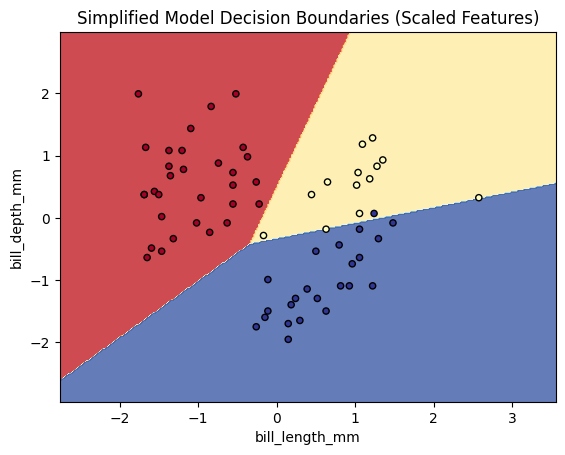

Decision boundaries for the simplified model visualized.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas here for DataFrame creation

def plot_decision_boundaries(X, y, model, title):
    # Create a meshgrid to plot decision boundaries
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Make predictions on the meshgrid, converting to DataFrame to retain feature names
    # Use the column names from the input X DataFrame
    mesh_data = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)
    Z = model.predict(mesh_data)
    Z = Z.reshape(xx.shape)

    # Plot the decision boundaries and data points
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.show()

# Visualize decision boundaries for the simplified model on the scaled test data
plot_decision_boundaries(X_test_best, y_test_best, model_best, 'Simplified Model Decision Boundaries (Scaled Features)')
print("Decision boundaries for the simplified model visualized.")

## Final Task

### Subtask:
Conclude the feature selection process by summarizing the findings, including the comparison of model accuracies and the implications of simplifying the model.


## Summary:

### Q&A
*   **Comparison of model accuracies:** The baseline Logistic Regression model, using all four features ('bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g') and scaled data, achieved an accuracy of 1.0000. The simplified model, using only 'bill_length_mm' and 'bill_depth_mm' with scaled data, achieved an accuracy of 0.9701.
*   **Implications of simplifying the model:** The simplified model's accuracy (0.9701) is within a 5% difference from the baseline model's accuracy (1.0000), specifically a difference of 2.99%. This indicates that a more parsimonious model with fewer features can achieve comparable performance, suggesting successful feature reduction without significant loss of predictive power.

### Data Analysis Key Findings
*   The 'penguins' dataset was loaded, and missing values were removed, resulting in a cleaned DataFrame with 333 entries.
*   The 'species' target variable was successfully encoded numerically as 'Adelie': 0, 'Chinstrap': 1, and 'Gentoo': 2.
*   Correlation analysis revealed a high correlation (0.87) between 'flipper_length_mm' and 'body_mass_g', exceeding the 0.85 threshold for redundancy.
*   An initial baseline Logistic Regression model trained on unscaled data achieved an accuracy of 0.9851 but showed a `ConvergenceWarning`.
*   After scaling the numerical features using `StandardScaler`, the baseline Logistic Regression model achieved a perfect accuracy of 1.0000 on the test set, resolving the convergence issue.
*   A simplified Logistic Regression model, trained with only 'bill_length_mm' and 'bill_depth_mm' (due to the redundancy of 'flipper_length_mm' and 'body_mass_g'), achieved an accuracy of 0.9701.
*   The accuracy of the simplified model (0.9701) was deemed acceptable, being within 2.99% of the full feature model's accuracy (1.0000), leading to the adoption of the simpler model.
*   Decision boundaries for the simplified model were successfully visualized, demonstrating its ability to separate different penguin species based on the selected features.

### Insights or Next Steps
*   Feature reduction through correlation analysis effectively simplified the model while retaining high predictive accuracy, demonstrating a good trade-off between model complexity and performance.
*   The high correlation between 'flipper_length_mm' and 'body_mass_g' suggests that these features convey similar information about penguin species, making one of them (or both) redundant for classification purposes when using the other.
